In [1]:
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import os
os.environ['ESMFMKFILE'] = 'C:/Users/eving/AppData/Local/miniconda3/envs/evalprecextremes/Library/lib/esmf.mk'
import xesmf as xe
import numpy as np
np.float_ = np.float64
from metpy.units import units
import matplotlib.colors as mcolors
from clisops.core import subset
from metpy.plots import ctables
import matplotlib.ticker as ticker
import cmaps
import geopandas as gpd
import seaborn as sns
from shapely.geometry import Point, Polygon
import rioxarray
from math import nan
from scipy import stats
import statsmodels.api as sm
from collections import OrderedDict
from matplotlib.pyplot import xticks

In [49]:
# Original Projection
projorig_name  = "PlateCarree"
projorig_dict  = dict()
projorig       = ccrs.__dict__[projorig_name].__call__(**projorig_dict)

# Graphic projection
projplot       = "LambertConformal"
projplot_dict  = dict(central_longitude=10.5, central_latitude=49.5, standard_parallels=(33,45))
projplot       = ccrs.__dict__[projplot].__call__(**projplot_dict)


C:\Users\eving\AppData\Local\Temp\ipykernel_9228\3094428374.py:11: FutureWarning: In a future version, xarray will not decode the variable 'timescale' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dsObs1 = xr.load_dataset(folder_obs+fObs, engine="netcdf4")
C:\Users\eving\AppData\Local\Temp\ipykernel_9228\3094428374.py:28: FutureWarning: In a future version, xarray will not decode the variable 'timescale' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype'

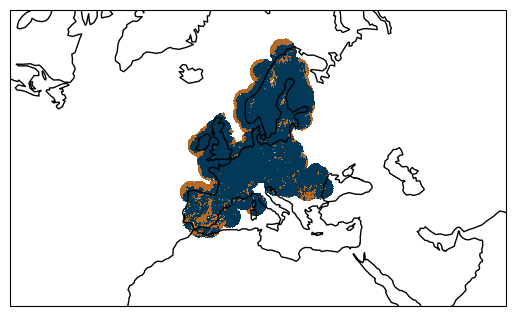

In [ ]:
diff = "rel"

season = "JJA"

# folder for the observations
folder_obs = 'D:/EUROCORDEX_extremes/output_cnrm_apr/'

# CERRA
obs1 = 'OBS_CERRALAND_011EUi_1986-2020'
fObs = f'{obs1}_{season}_max_scale_S1.nc'
dsObs1 = xr.load_dataset(folder_obs+fObs, engine="netcdf4")
max_array1 = dsObs1.maxpr.values[dsObs1.year>2012,0,:,:]
meanmax1 = np.mean(max_array1, axis=0)
dsObs1_clean = xr.Dataset(
   data_vars={"meanmax": (("lat", "lon"), meanmax1)},
    coords={
        "lon": dsObs1.lon.values,
        "lat": dsObs1.lat.values,
    }
)
dsObs1_clean = dsObs1_clean.cf.add_bounds(["lon","lat"])


# EURAD
agg = 24
obs2 = 'OBS_EURADCLIM_011EUi_2013-2022'
fObs = f'{obs2}_{season}_max_scale_S1.nc'
dsObs2 = xr.load_dataset(folder_obs+fObs, engine="netcdf4")
max_array2 = dsObs2.maxpr.values[dsObs2.year<2021,4,:,:]
meanmax2 = np.mean(max_array2, axis=0)
dsObs2_clean = xr.Dataset(
    data_vars={"meanmax": (("lat", "lon"), meanmax2)},
    coords={
        "lon": dsObs2.lon.values,
        "lat": dsObs2.lat.values,
    }
)
dsObs2_clean = dsObs2_clean.cf.add_bounds(["lon","lat"])

# regrid obs
regridder = xe.Regridder(
    dsObs2_clean, dsObs1_clean, "conservative", unmapped_to_nan=True, ignore_degenerate=True
)
ds2_regrid = regridder(dsObs2_clean, keep_attrs=True)

X = dsObs1_clean.lon
Y = dsObs1_clean.lat

Z1 = meanmax1
Z2 = ds2_regrid.meanmax.values
Z = (Z2/Z1 - 1)*100


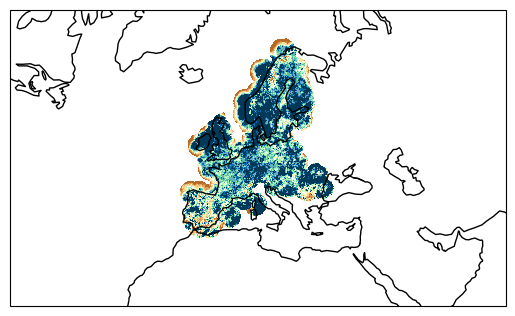

In [51]:

fig, ax = plt.subplots(subplot_kw={'projection': projplot})

plot = ax.pcolormesh(X, Y, Z, cmap=cmaps.precip_diff_12lev, vmin=-65,vmax=65,transform=projorig, zorder=1)
    
# add coastlines
ax.add_feature(cfeature.COASTLINE, linewidth=1)        # Draw coastlines


In [35]:
meanmax2.shape

(408, 881)

62202.0
55018.0
50225.0
48188.0


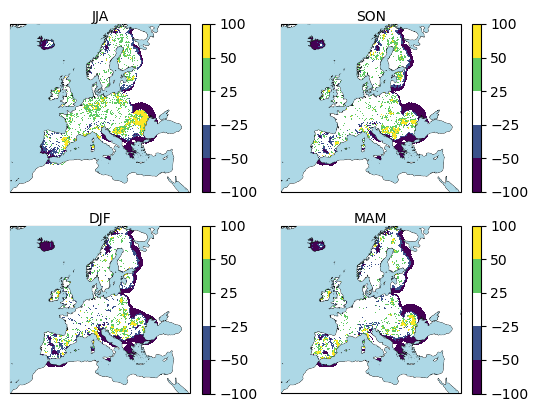

In [ ]:
fig, axes = plt.subplots(nrows=2,ncols=2,subplot_kw={'projection': projplot})

diff = "rel"

seasons = ["JJA","SON","DJF","MAM"]

# choose a season
for ax, season in zip(axes.flat, seasons):
    quantile = 'perc_99.00'

    # folder for the observations
    folder_obs = 'D:/EUROCORDEX_extremes/output_cnrm_apr/'

    # CERRA
    obs1 = 'OBS_CERRALAND_011EUi_1986-2020'
    fObs = f'{obs1}_{season}_all_24h_perc.nc'
    dsObs = xr.load_dataset(folder_obs+fObs, engine="netcdf4")
    ds1 = dsObs.cf.add_bounds(["lon","lat"])

    # EURAD
    agg = 24
    obs2 = 'OBS_EURADCLIM_011EUi_2013-2022'
    fObs = f'{obs2}_{season}_all_{agg}h_perc.nc'
    dsObs = xr.load_dataset(folder_obs+fObs, engine="netcdf4")
    ds2 = dsObs.cf.add_bounds(["lon","lat"])

    # regrid obs
    regridder = xe.Regridder(
        ds2, ds1, "conservative", unmapped_to_nan=True, ignore_degenerate=True
    )
    ds2_regrid = regridder(ds2, keep_attrs=True)


    X = ds2.lon
    Y = ds2.lat
    ZOBS = ds1[quantile]
    ZMOD = ds2[quantile]
    Z = (ZMOD / ZOBS - 1) * 100 # Calculate percentage difference


    # 2. Define discrete bin edges (can be non-uniform)
    bounds = [-100, -50, -25, 25, 50, 100]
    n_bins = len(bounds) - 1

    # 3. Get a continuous colormap and discretize it to match the number of bins
    base_cmap = plt.get_cmap("viridis")
    discrete_cmap = base_cmap.resampled(n_bins)
    discrete_cmap.colors[2] = [1,1,1,1]

    # 4. Create the BoundaryNorm mapping data ranges to the discrete colors
    norm = mcolors.BoundaryNorm(bounds, n_bins)

    # 1. Define your 4 colors (using named colors, hex codes, or RGB tuples)
    plot = ax.pcolormesh(X, Y, Z,  cmap=discrete_cmap, norm=norm, transform=projorig, zorder=1)

    ax.set_extent((-15, 38, 25, 70))  # France zoom
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)        # Draw coastlines
    ax.add_feature(cfeature.OCEAN, facecolor='LightBlue', zorder=10)

    cbar = fig.colorbar(plot, ax=ax, ticks=bounds, spacing="uniform")

    ax.set_title(season, fontsize=10, pad=1.0)

    # save mask
    ZZ = Z.values
    ZZ[np.isnan(ZZ)] = 1000
    mask = np.abs(ZZ) > 50

    if(season == "JJA"):
        unimask = ZZ
        unimask[mask] = 0
        unimask[~mask] = 1
    else:
        unimask[mask] = 0
    
    print(np.sum(unimask))


np.save('D:/EUROCORDEX_extremes/figures_25Jun/mask_eurad.npy', unimask)




In [31]:
np.unique(mask)

array([False,  True])

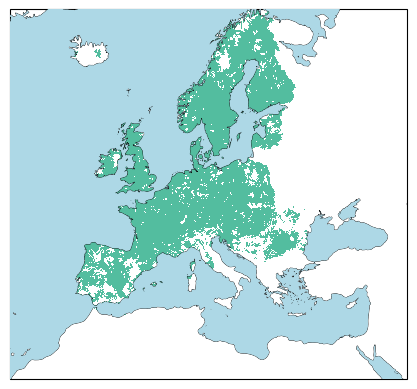

In [36]:
fig, ax = plt.subplots(subplot_kw={'projection': projplot})
plot = ax.pcolormesh(X, Y, unimask, cmap=cmaps.precip_diff_12lev, vmin=-2, vmax=2,
                    transform=projorig, zorder=1)


ax.set_extent((-15, 38, 25, 70))  # France zoom
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)        # Draw coastlines
ax.add_feature(cfeature.OCEAN, facecolor='LightBlue', zorder=10)